In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import sys

sys.path.append('..')  # Add Code directory to path

# # Import utils package
from utils import (
    CholeskyBootstrapReturns,
    BlockBootstrapReturnsLoader,
    ControlMatrixPolicy,
    load_historical_returns,
    sample_without_replacement,
    SigmoidWealthPenalty,
    CRRAUtility,
    simulate_wealth_trajectory,
    project_onto_simplex
)

# Import new modular spending components
from utils.spending import *
from utils.allocation import *
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

torch.cuda.is_available()

OSError: [WinError 1114] A dynamic link library (DLL) initialization routine failed. Error loading "c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\lib\c10.dll" or one of its dependencies.

## Configuration Parameters

In [22]:
# ============================================================================
# SIMULATION PARAMETERS
# ============================================================================
N_ASSETS = 3
N_SIMULATIONS = 500_000
SIMULATION_YEARS = 35
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
RETURN_SAMPLER = "block_bootstrap"  # Options: "cholesky" or "block_bootstrap"
RETURN_SAMPLER = "cholesky" 

# ============================================================================
# WEALTH & SPENDING PARAMETERS
# ============================================================================
INITIAL_WEALTH_RANGE = range(500_000, 1_050_000, 50_000)  # $350k to $1M in $50k increments
DESIRED_SPENDING = EXPENDITURE_GUIDELINES['choices_metro_couple']
SPENDING_DECLINE_RATE = 0.02
CONSUMPTION_FLOOR = EXPENDITURE_GUIDELINES['no_frills_metro_couple']
FLOOR_DECLINE_RATE = 0.00
INCOME_TYPE = "couple"  # Options: "couple", "single", "single_sharing", or None

# ============================================================================
# OPTIMIZATION PARAMETERS
# ============================================================================
# Initial policy weights (will be optimized)
INITIAL_POLICY = [0.1, 0.9]  # [Asset 0, Asset 1] weights (Asset 2 is implicit)

# Optimizer settings
OPTIMIZER_TYPE = "SGD"  # Options: "Adam" or "SGD"
INITIAL_LR = 0.1  # Increased for better exploration
MAX_ITERATIONS = 2000
MOMENTUM = 0.9  # For SGD optimizer

# Learning rate schedule (ReduceLROnPlateau)
LR_DECAY_FACTOR = 0.5  # Factor to reduce learning rate
LR_PATIENCE = 6  # Iterations without improvement before reducing LR
LR_THRESHOLD = 1e-5  # Minimum change to qualify as improvement

# Random restart to escape local optima
USE_RANDOM_RESTARTS = False  # Enable random restarts
RESTART_PATIENCE = 150  # Iterations without improvement before random restart
RESTART_NOISE_SCALE = 0.3  # How much to perturb the policy during restart

# Early stopping
STOPPING_PATIENCE = 30  # Iterations without improvement before stopping

# Progress reporting
PRINT_EVERY = 20  # Print progress every N iterations

# ============================================================================
# OBJECTIVE FUNCTION PARAMETERS
# ============================================================================
CRRA_GAMMA = 5.0
CRRA_FLOOR = EXPENDITURE_GUIDELINES['no_frills_metro_couple']
WEALTH_PENALTY_STEEPNESS = 1e-3

## Load Data

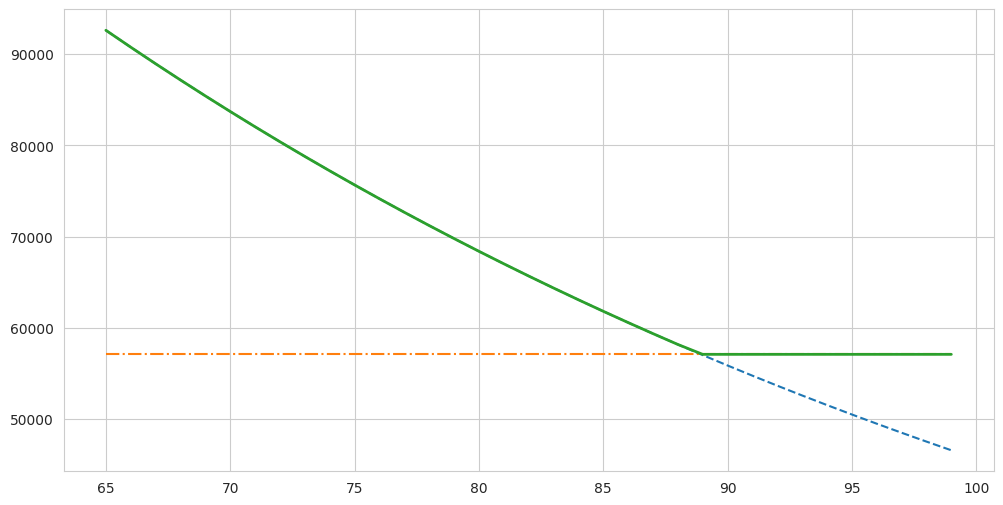

In [23]:
t = np.arange(0, SIMULATION_YEARS)
desired_spending_over_time = DESIRED_SPENDING * (1 - SPENDING_DECLINE_RATE) ** t
consumption_floor_over_time = CONSUMPTION_FLOOR * (1 - FLOOR_DECLINE_RATE) ** t
spending = np.maximum(desired_spending_over_time, consumption_floor_over_time)

plt.figure(figsize=(12, 6))
plt.plot(t+65, desired_spending_over_time, label='Desired Spending', linestyle='--')
plt.plot(t+65, consumption_floor_over_time, label='Consumption Floor', linestyle='-.')
plt.plot(t+65, spending, label='Effective Spending', linewidth=2)

In [24]:
tax_rates = np.loadtxt("./Data/IID Data/Final/tax_rates.csv", delimiter=",", skiprows=1)
if RETURN_SAMPLER == "cholesky":
    exp_returns = np.loadtxt("./Data/IID Data/Final/expected_returns.csv", delimiter=",", skiprows=1)
    cov_matrix = np.loadtxt("./Data/IID Data/Final/covariance.csv", delimiter=",", skiprows=1, usecols=range(1, N_ASSETS+2))
    return_sampler = CholeskyBootstrapReturns(exp_returns, cov_matrix)
else:
    return_sampler = BlockBootstrapReturnsLoader("./Data/Returns/Final/block_bootstrapped_paths.npy")

In [25]:
import dataclasses
import pickle
import os

@dataclasses.dataclass
class SimulationConfig:
    # Simulation parameters
    N_ASSETS: int
    N_SIMULATIONS: int
    SIMULATION_YEARS: int
    RETURN_SAMPLER: str
    
    # Wealth & spending parameters
    INITIAL_WEALTH: float
    DESIRED_SPENDING: float
    SPENDING_DECLINE_RATE: float
    CONSUMPTION_FLOOR: float 
    FLOOR_DECLINE_RATE: float 
    INCOME_TYPE: str
    
    # Optimization parameters
    INITIAL_POLICY: list
    OPTIMIZER_TYPE: str


@dataclasses.dataclass
class OptimizationResult:
    best_policy: np.ndarray
    best_utility: float
    policy_history: np.ndarray
    cost_history: np.ndarray
    wealth_simulated: np.ndarray
    consumption_simulated: np.ndarray
    cumulative_inflation: np.ndarray


def experiment_file(config: SimulationConfig):
    return f"experiment_{config.INITIAL_WEALTH}_{config.RETURN_SAMPLER}.pkl"

def save_experiment(config: SimulationConfig, result: OptimizationResult):
    filename = experiment_file(config)
    with open(filename, 'wb') as f:
        pickle.dump({'config': config, 'result': result}, f)
    print(f"Experiment saved to {filename}")

## Optimization

In [26]:
# Setup optimizer and learning rate scheduler
from IPython.display import clear_output

for INITIAL_WEALTH in INITIAL_WEALTH_RANGE:

    sim_config = SimulationConfig(
        N_ASSETS=N_ASSETS,
        N_SIMULATIONS=N_SIMULATIONS,
        SIMULATION_YEARS=SIMULATION_YEARS,
        RETURN_SAMPLER=RETURN_SAMPLER,
        INITIAL_WEALTH=INITIAL_WEALTH,
        DESIRED_SPENDING=DESIRED_SPENDING,
        SPENDING_DECLINE_RATE=SPENDING_DECLINE_RATE,
        CONSUMPTION_FLOOR=CONSUMPTION_FLOOR,
        FLOOR_DECLINE_RATE=FLOOR_DECLINE_RATE,
        INCOME_TYPE=INCOME_TYPE,
        INITIAL_POLICY=INITIAL_POLICY,
        OPTIMIZER_TYPE=OPTIMIZER_TYPE
    )
        
    # Configure spending and allocation policies
    desired_spending = DecliningRealSpending(DESIRED_SPENDING, decline_rate=SPENDING_DECLINE_RATE)
    consumption_floor = DecliningRealFloor(init_floor=CONSUMPTION_FLOOR, decline_rate=FLOOR_DECLINE_RATE)
    income = NZSuper(INCOME_TYPE)

    spending_policy = SpendingPolicy(
        spending=desired_spending,
        floor=consumption_floor,
        income=income
    )
    allocation_policy = ConstantAllocation(N_ASSETS, N_SIMULATIONS, DEVICE)

    # Initialize policy and generate returns
    policy = torch.tensor(INITIAL_POLICY, device=DEVICE, dtype=torch.float32, requires_grad=True)  
    returns, cumulative_inflation = return_sampler.generate(N_SIMULATIONS, SIMULATION_YEARS)
    returns = returns - tax_rates
    returns = torch.tensor(returns, device=DEVICE)
    cumulative_inflation = torch.tensor(cumulative_inflation, device=DEVICE)

    # Choose optimizer based on configuration
    if OPTIMIZER_TYPE == "Adam":
        optimizer = torch.optim.Adam([policy], lr=INITIAL_LR)
    else:  # SGD
        optimizer = torch.optim.SGD([policy], lr=INITIAL_LR, momentum=MOMENTUM)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, 
        mode='min',  # Minimize cost
        factor=LR_DECAY_FACTOR,  # Multiply LR by this factor
        patience=LR_PATIENCE,  # Wait this many iterations before reducing LR
        threshold=LR_THRESHOLD,  # Minimum change to qualify as improvement
    )

    cost_history = []
    policy_history = []  # Track policy over time

    # Tracking variables
    best_cost = float('inf')
    best_policy = policy.data.clone()
    iterations_without_improvement = 0

    # Initialize objective functions once (outside loop)
    crra_objective = CRRAUtility(gamma=CRRA_GAMMA, consumption_floor=consumption_floor, normalize=True)
    wealth_penalty = SigmoidWealthPenalty(steepness=WEALTH_PENALTY_STEEPNESS)
    iterations_since_restart = 0

    for i in range(MAX_ITERATIONS):
        # Zero gradients from previous iteration
        optimizer.zero_grad()

        wealth, consumption = simulate_wealth_trajectory(
            returns=returns,
            cumulative_inflation=cumulative_inflation,
            allocation_policy=allocation_policy,
            spending_policy=spending_policy,
            initial_wealth=INITIAL_WEALTH,
            policy_settings=policy
        )
        cost = crra_objective.evaluate(wealth, consumption, cumulative_inflation=cumulative_inflation)
        cost += wealth_penalty.evaluate(wealth, consumption)
        
        # Backward pass
        cost.backward()
        
        # Update weights
        optimizer.step()
        
        # Project onto feasible set (constraints: x >= 0, sum(x) <= 1)
        with torch.no_grad():
            policy.data = project_onto_simplex(policy.data)

        # Record history
        cost_history.append(cost.item())
        policy_history.append(policy.data.cpu().numpy().copy())
        
        # Update learning rate based on cost (ReduceLROnPlateau)
        scheduler.step(cost.item())
        
        # Check for cost improvement
        if cost.item() < best_cost:
            best_cost = cost.item()
            best_policy = policy.data.clone()
            iterations_without_improvement = 0
            iterations_since_restart = 0
        else:
            iterations_without_improvement += 1
            iterations_since_restart += 1
        
        # Early stopping criterion
        if iterations_without_improvement >= STOPPING_PATIENCE:
            print(f"\n{'='*70}")
            print(f"EARLY STOPPING at iteration {i + 1}")
            print(f"No improvement in {STOPPING_PATIENCE} iterations")
            print(f"{'='*70}")
            break

        # Progress reporting
        if (i + 1) % PRINT_EVERY == 0 or i == 0:
            clear_output(wait=True)
            
            current_lr = optimizer.param_groups[0]['lr']
            cost_change = cost_history[-1] - cost_history[-2] if len(cost_history) > 1 else 0
            print(f"{'='*70}")
            print(f"OPTIMIZING FOR INITIAL WEALTH: ${INITIAL_WEALTH:,.0f}")
            print(f"Iteration {i + 1:,}/{MAX_ITERATIONS:,} ({(i+1)/MAX_ITERATIONS*100:.1f}%) | LR: {current_lr:.6f}")
            print(f"{'='*70}")
            print(f"Cost:                      {cost.item():.6f}")
            print(f"Cost change:               {cost_change:.8f} (threshold: {LR_THRESHOLD})")
            print(f"Best Cost:                 {best_cost:.6f}")
            print(f"Iterations w/o improve:    {iterations_without_improvement}/{STOPPING_PATIENCE}")
            if USE_RANDOM_RESTARTS:
                print(f"Iterations since restart:  {iterations_since_restart}/{RESTART_PATIENCE}")
            print(f"{'-'*70}")
            print(f"Current policy:            {policy.data.cpu().numpy()}")
            print(f"Best policy:               {best_policy.cpu().numpy()}")
            print(f"{'-'*70}")
            print(f"Mean consumption:          ${consumption.mean().item():,.0f}")
            print(f"Mean terminal wealth:      ${wealth[:, -1].mean().item():,.0f}")
            print(f"Bankruptcy rate:           {(wealth[:, -1] == 0).sum().item() / N_SIMULATIONS:.2%}")
            # bankruptcy density is the total number of times wealth hits zero across all time steps and simulations, divided by total time steps and simulations
            bankruptcy_density = (wealth == 0).sum().item() / (N_SIMULATIONS * SIMULATION_YEARS)
            
            # impoverishment density is the total number of times consumption falls below the floor across all time steps and simulations, divided by total time steps and simulations
            floor = consumption_floor.calculate_tensor(wealth=wealth, cumulative_inflation=cumulative_inflation)
            impoverishment_density = (consumption < floor).sum().item() / (N_SIMULATIONS * SIMULATION_YEARS)

            print(f"Impoverishment density:    {impoverishment_density:.4%}")
            print(f"Bankruptcy density:        {bankruptcy_density:.4%}")
            print(f"{'='*70}")

    # Restore best policy found
    with torch.no_grad():
        policy.data = best_policy

    # Convert policy history to numpy array for easier analysis
    policy_history = np.array(policy_history)
    cost_history = np.array(cost_history)

    # Final summary
    print(f"\n{'='*70}")
    print(f"OPTIMIZATION COMPLETE")
    print(f"{'='*70}")
    print(f"Total iterations:          {len(cost_history):,}")
    print(f"Final cost:                {cost_history[-1]:.6f}")
    print(f"Best cost:                 {best_cost:.6f}")
    print(f"Best policy found:         {best_policy.cpu().numpy()}")
    print(f"{'='*70}")
    
    
    final_simulated_wealth, final_simulated_consumption = simulate_wealth_trajectory(
        returns=returns,
        cumulative_inflation=cumulative_inflation,
        allocation_policy=allocation_policy,
        spending_policy=spending_policy,
        initial_wealth=INITIAL_WEALTH,
        policy_settings=policy
    )
    
    result = OptimizationResult(
        best_policy=best_policy.detach().cpu().numpy(),
        best_utility=-best_cost,  # Convert back to utility
        policy_history=policy_history,
        cost_history=cost_history,
        wealth_simulated=final_simulated_wealth.detach().cpu().numpy(),
        consumption_simulated=final_simulated_consumption.detach().cpu().numpy(),
        cumulative_inflation=cumulative_inflation.detach().cpu().numpy(),
    )
    print(f"Saving experiment results...")
    save_experiment(sim_config, result)


OPTIMIZING FOR INITIAL WEALTH: $1,000,000
Iteration 420/2,000 (21.0%) | LR: 0.100000
Cost:                      -1.419809
Cost change:               -0.00000002 (threshold: 1e-05)
Best Cost:                 -1.419809
Iterations w/o improve:    15/30
----------------------------------------------------------------------
Current policy:            [0.27741253 0.36838865]
Best policy:               [0.27741647 0.3683892 ]
----------------------------------------------------------------------
Mean consumption:          $105,344
Mean terminal wealth:      $686,610
Bankruptcy rate:           3.51%
Impoverishment density:    0.7896%
Bankruptcy density:        0.5014%

EARLY STOPPING at iteration 435
No improvement in 30 iterations

OPTIMIZATION COMPLETE
Total iterations:          435
Final cost:                -1.419809
Best cost:                 -1.419809
Best policy found:         [0.27741647 0.3683892 ]
Saving experiment results...
Experiment saved to experiment_1000000_cholesky.pkl


## Results & Visualization

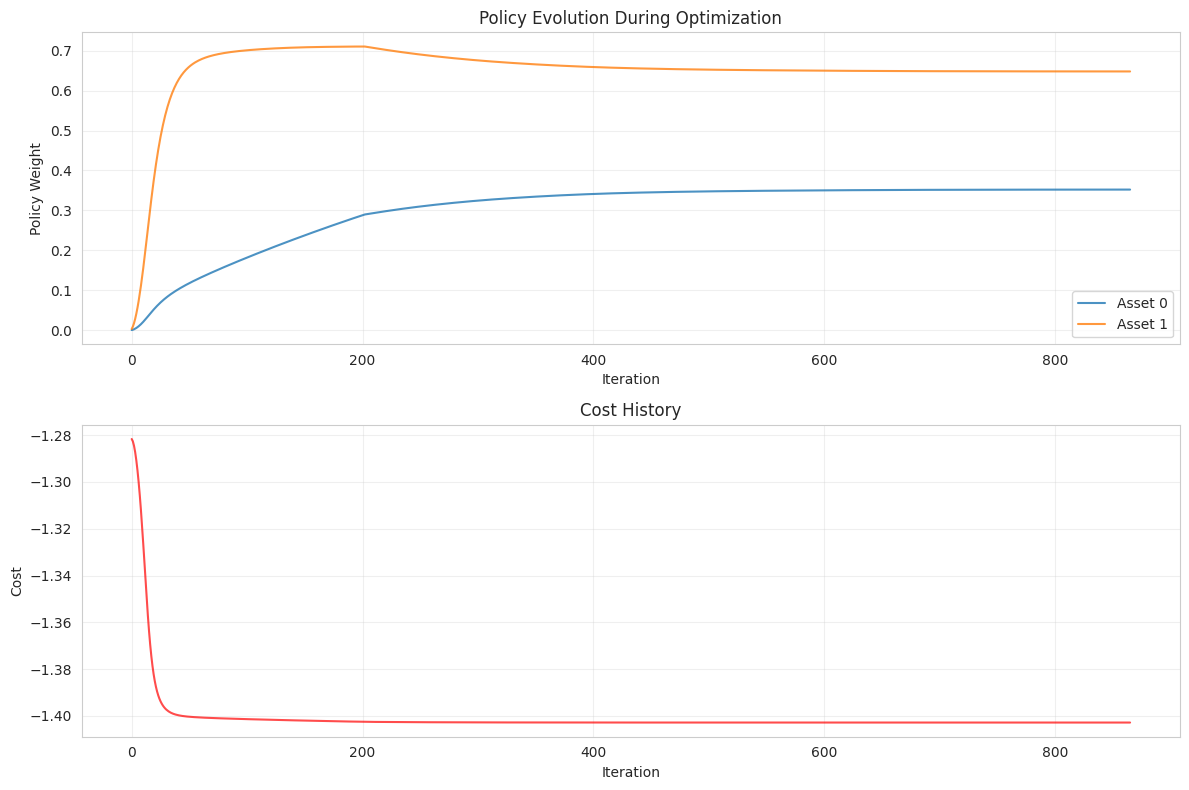


Final policy: tensor([0.3521, 0.6479], device='cuda:0')
Final cost: -1.402807
Best cost: -1.402808
Total iterations: 866


In [ ]:
# Visualize policy evolution over time
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
# Plot 1: Policy weights over time
policy_history = np.array(policy_history)
for asset_idx in range(policy_history.shape[1]):
    axes[0].plot(policy_history[:, asset_idx], label=f'Asset {asset_idx}', alpha=0.8)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Policy Weight')
axes[0].set_title('Policy Evolution During Optimization')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Cost history
axes[1].plot(cost_history, color='red', alpha=0.7)
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Cost')
axes[1].set_title('Cost History')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal policy: {policy.data}")
print(f"Final cost: {cost_history[-1]:.6f}")
print(f"Best cost: {best_cost:.6f}")
print(f"Total iterations: {len(cost_history)}")

## Analysis: Optimized Policy Performance

In [18]:
# View optimized policy weights
print(f"Optimized policy weights: {policy.data.cpu().numpy()}")
print(f"Implicit weight (remaining): {1 - policy.data.sum().item():.4f}")
policy


Optimized policy weights: [0.35210755 0.6478925 ]
Implicit weight (remaining): 0.0000


tensor([0.3521, 0.6479], device='cuda:0', requires_grad=True)

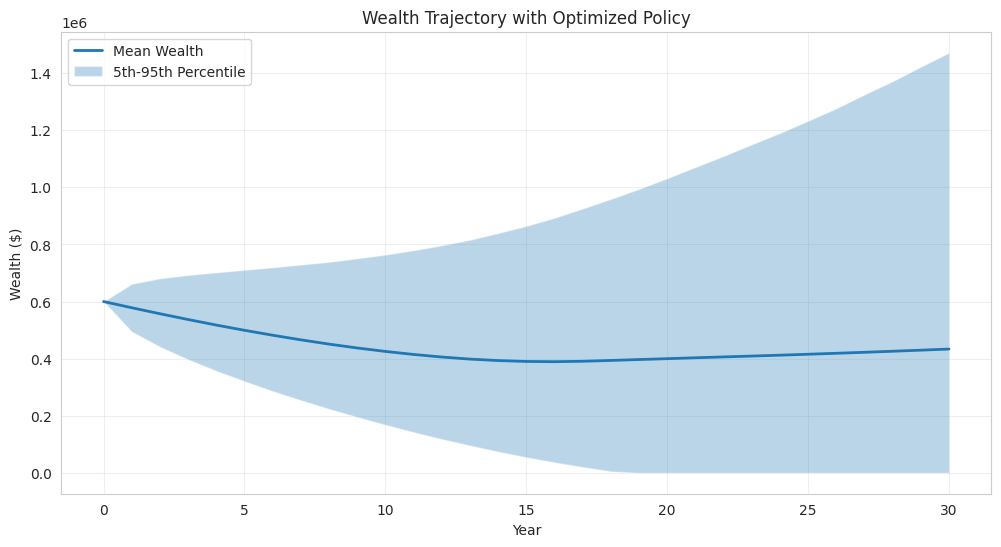

In [19]:
# Simulate wealth trajectory with optimized policy
wealth, consumption = simulate_wealth_trajectory(
    returns=returns,
    cumulative_inflation=cumulative_inflation,
    allocation_policy=allocation_policy,
    spending_policy=spending_policy,
    initial_wealth=INITIAL_WEALTH,
    policy_settings=policy
)

# Plot wealth over time
avg_wealth = wealth.detach().mean(dim=0).cpu().numpy()
_95_percentile = torch.quantile(wealth.detach(), 0.95, dim=0).cpu().numpy()
_05_percentile = torch.quantile(wealth.detach(), 0.05, dim=0).cpu().numpy()

plt.figure(figsize=(12, 6))
plt.plot(avg_wealth, label='Mean Wealth', linewidth=2)
plt.fill_between(range(len(avg_wealth)), _05_percentile, _95_percentile, alpha=0.3, label='5th-95th Percentile')
plt.xlabel('Year')
plt.ylabel('Wealth ($)')
plt.title('Wealth Trajectory with Optimized Policy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

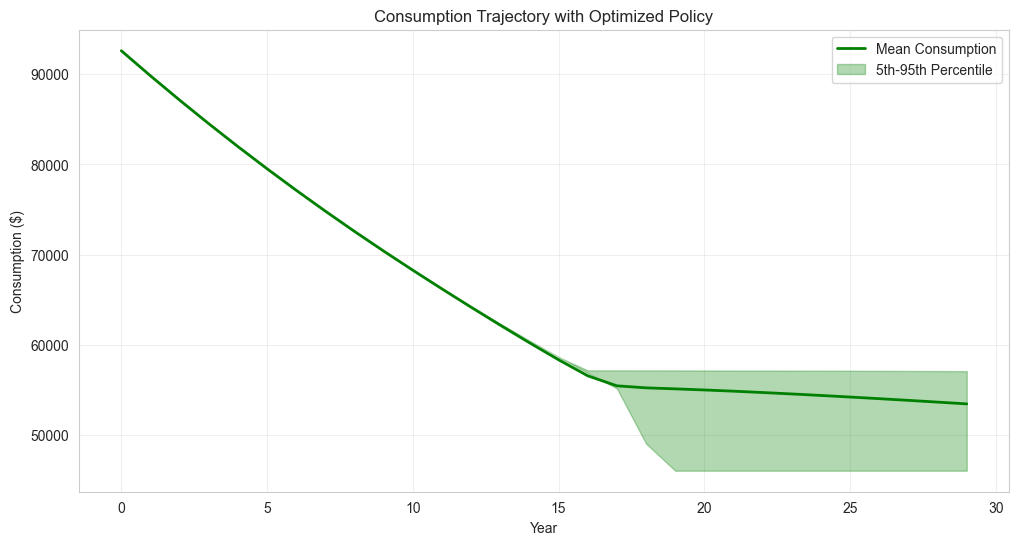

In [25]:
# Plot REAL consumption over time

cumulative_inflation_np = cumulative_inflation.cpu().numpy()
consumption_np = consumption.detach().cpu().numpy() # Adjust for inflation to get real consumption
real_consumption = consumption_np / cumulative_inflation_np 

avg_consumption = real_consumption.mean(axis=0)
_95_percentile_c = np.quantile(real_consumption, 0.95, axis=0)
_05_percentile_c = np.quantile(real_consumption, 0.05, axis=0)

plt.figure(figsize=(12, 6))
plt.plot(avg_consumption, label='Mean Consumption', linewidth=2, color='green')
plt.fill_between(range(len(avg_consumption)), _05_percentile_c, _95_percentile_c, alpha=0.3, label='5th-95th Percentile', color='green')
plt.xlabel('Year')
plt.ylabel('Consumption ($)')
plt.title('Consumption Trajectory with Optimized Policy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [23]:
real_consumption.shape

(500000, 30)